In [1]:
#IMPORT FUNCTIONS ANS DEFINE START_DATE AND END_DATE
#ONLY CHANGE THIS CELL IF ADJUSTED FOR YEARS
import numpy as np
import pandas as pd
import os
from os import listdir
from os.path import isfile, join
import requests
import datetime as dt
from fetch_data import *
from dateutil.relativedelta import relativedelta
pd.set_option('display.max_rows', 50)

# Define start and end dates
start_date = dt.datetime(2016, 1, 1)
end_date = dt.datetime(2025, 12, 31)

#Define API KEY MAQ-Observations
site = 1                                          #1=Veenkampen
variables = ['SW_IN_1_1_1','TA_1_1_2','RH_1_1_1','WS_1_1_1','P_1_1_7','VWC_1_1_1','VWC_1_2_1','VWC_1_3_1','VWC_1_4_1']                                 
API_KEY = '2ece4599-3157-40bf-ae13-351e1eb3ae92'  #Put you API key here as a string, see https://maq-observations.nl/api/
save_filename = 'MAQ-Observations_request.csv'    #You can define the name of the file you want to save your data to

#OUTPUT FILE WILL BE:
#Data_Meteo_Veenkampen_{start_date.year}-{end_date.year}.csv

#EXAMPLE DATA FORMAT FROM OLD DATA
'''
date-time;year;month;day-of-month;hour;Rg;Ta;RH;u;P;smc_065;smc_125;smc_250;smc_500
2013-01-01 0:00;2013;1;1;0;0.0;8.6;90.04;8.6;1.0;0.71;0.69;0.69;0.74
2013-01-01 1:00;2013;1;1;1;0.0;8.4;91.31;8.1;2.0;0.71;0.69;0.69;0.74
2013-01-01 2:00;2013;1;1;2;0.0;8.3;91.62;7.5;0.6;0.71;0.69;0.69;0.74
2013-01-01 3:00;2013;1;1;3;0.0;8.2;92.01;6.7;1.8;0.71;0.69;0.69;0.74
2013-01-01 4:00;2013;1;1;4;0.0;8.2;92.67;7.1;1.3;0.71;0.69;0.69;0.74
2013-01-01 5:00;2013;1;1;5;0.0;8.2;92.98;6.7;0.4;0.71;0.69;0.69;0.74
2013-01-01 6:00;2013;1;1;6;0.0;8.3;93.38;6.9;0.1;0.71;0.69;0.69;0.74
2013-01-01 7:00;2013;1;1;7;0.0;8.4;92.55;6.4;4.3;0.71;0.69;0.69;0.74
2013-01-01 8:00;2013;1;1;8;0.0;8.4;91.76;6.1;1.7;0.71;0.69;0.69;0.74
2013-01-01 9:00;2013;1;1;9;7.8;7.9;92.69;3.7;0.2;0.71;0.69;0.69;0.74
'''

'\ndate-time;year;month;day-of-month;hour;Rg;Ta;RH;u;P;smc_065;smc_125;smc_250;smc_500\n2013-01-01 0:00;2013;1;1;0;0.0;8.6;90.04;8.6;1.0;0.71;0.69;0.69;0.74\n2013-01-01 1:00;2013;1;1;1;0.0;8.4;91.31;8.1;2.0;0.71;0.69;0.69;0.74\n2013-01-01 2:00;2013;1;1;2;0.0;8.3;91.62;7.5;0.6;0.71;0.69;0.69;0.74\n2013-01-01 3:00;2013;1;1;3;0.0;8.2;92.01;6.7;1.8;0.71;0.69;0.69;0.74\n2013-01-01 4:00;2013;1;1;4;0.0;8.2;92.67;7.1;1.3;0.71;0.69;0.69;0.74\n2013-01-01 5:00;2013;1;1;5;0.0;8.2;92.98;6.7;0.4;0.71;0.69;0.69;0.74\n2013-01-01 6:00;2013;1;1;6;0.0;8.3;93.38;6.9;0.1;0.71;0.69;0.69;0.74\n2013-01-01 7:00;2013;1;1;7;0.0;8.4;92.55;6.4;4.3;0.71;0.69;0.69;0.74\n2013-01-01 8:00;2013;1;1;8;0.0;8.4;91.76;6.1;1.7;0.71;0.69;0.69;0.74\n2013-01-01 9:00;2013;1;1;9;7.8;7.9;92.69;3.7;0.2;0.71;0.69;0.69;0.74\n'

In [2]:
# Transform the data to the desired format
def transform_data(df):
    # Extract year, month, day, and hour from the 'begindatumtijd' column
    df['date-time'] = pd.to_datetime(df['date-time'])
    df['date-time'] = df['date-time'].dt.strftime('%Y-%m-%d %H:%M:%S')

    df["date-time"] = pd.to_datetime(df["date-time"])  # Ensure datetime format
    df.set_index("date-time", inplace=True)  # Set datetime as index

    agg_rules = {
        "Rg": lambda x: np.nanmean(x),
        "Ta": lambda x: np.nanmean(x),
        "RH": lambda x: np.nanmean(x),
        "u": lambda x: np.nanmean(x),
        "P": lambda x: np.nansum(x),
        "smc_065": lambda x: np.nanmean(x),
        "smc_125": lambda x: np.nanmean(x),
        "smc_250": lambda x: np.nanmean(x),
        "smc_500": lambda x: np.nanmean(x),
    }

    df_hourly = df.resample("H").agg(agg_rules)
    df_hourly = df_hourly.round(3)
    df_hourly.reset_index(inplace=True)

    df_hourly['year'] = df_hourly['date-time'].dt.year
    df_hourly['month'] = df_hourly['date-time'].dt.month
    df_hourly['day'] = df_hourly['date-time'].dt.day
    df_hourly['hour'] = df_hourly['date-time'].dt.hour

    # Reorder the columns to match the desired output
    df_hourly = df_hourly[["date-time", "year", "month", "day", "hour", "Rg", "Ta", "RH", "u", "P", "smc_065", "smc_125", "smc_250", "smc_500"]]
    
    return df_hourly

# Create a function to fill missing times with NaN
def fill_missing_times(df, start_date, end_date):
    # Create a complete time range from start_date to end_date with a frequency of 1 minute
    complete_time_range = pd.date_range(start=start_date, end=end_date, freq='H')
    
    # Create a DataFrame with the complete time range as 'date-time'
    complete_df = pd.DataFrame({'date-time': complete_time_range})
    
    # Ensure both 'date-time' columns are of datetime type
    complete_df['date-time'] = pd.to_datetime(complete_df['date-time'])
    df['date-time'] = pd.to_datetime(df['date-time'])
    
    # Merge the complete DataFrame with the existing data to ensure all times are included
    df = pd.merge(complete_df, df, on='date-time', how='left')
    
    # Reorder the columns and return the result
    df['year'] = df['date-time'].dt.year
    df['month'] = df['date-time'].dt.month
    df['day'] = df['date-time'].dt.day
    df['hour'] = df['date-time'].dt.hour
    df = df[["date-time", "year", "month", "day", "hour", "Rg", "Ta", "RH", "u", "P", "smc_065", "smc_125", "smc_250", "smc_500"]]
    
    return df

# Rename columns
column_mapping = {
    "Timestamp": "date-time",
    "SW_IN_1_1_1": "Rg",
    "TA_1_1_2": "Ta",
    "RH_1_1_1": "RH",
    "WS_1_1_1": "u",
    "P_1_1_7": "P",
    "VWC_1_1_1": "smc_065",
    "VWC_1_2_1": "smc_125",
    "VWC_1_3_1": "smc_250",
    "VWC_1_4_1": "smc_500",
}



In [3]:
#ACTUAL CODE (NO NEED TO CHANGE)

df_all = pd.DataFrame()
df_veenkampen_list = []

# Loop over each year from start_date to end_date
current_date = start_date
while current_date <= end_date:
    year = current_date.year
    month = current_date.month
    end_date_month = current_date + relativedelta(months=1)
    print("Processing year "+str(year)+" month "+str(month))

    month_data = fetch_data(current_date,end_date_month,site,variables,API_KEY,False,save_filename).drop(index=0).reset_index(drop=True)

    month_data = month_data.rename(columns=column_mapping)[["date-time", "Rg", "Ta", "RH", "u", "P", "smc_065", "smc_125", "smc_250", "smc_500"]]
    month_data_transformed = transform_data(month_data)
    month_data_filled = fill_missing_times(month_data_transformed, current_date, end_date_month)
    
    df_veenkampen_list.append(month_data_filled)

    current_date = current_date + relativedelta(months=1)
#ENDOFLOOP

# Concatenate all dataframes for each location into separate DataFrames
df_veenkampen_final = pd.concat(df_veenkampen_list, ignore_index=True)

# Save to .csv
df_veenkampen_final.to_csv(f"Data_Meteo_Veenkampen_{start_date.year}-{end_date.year}.csv", index=False, sep=";")

print("Veenkampen Data:")
print(df_veenkampen_final)


Processing year 2016 month 1
Processing variable SW_IN_1_1_1 at https://maq-observations.nl/wp-json/maq/v1/streams/48656/measures?from=2016-01-01&to=2016-02-01
Processing variable TA_1_1_2 at https://maq-observations.nl/wp-json/maq/v1/streams/48654/measures?from=2016-01-01&to=2016-02-01
Processing variable RH_1_1_1 at https://maq-observations.nl/wp-json/maq/v1/streams/48655/measures?from=2016-01-01&to=2016-02-01
Processing variable WS_1_1_1 at https://maq-observations.nl/wp-json/maq/v1/streams/48671/measures?from=2016-01-01&to=2016-02-01
Processing variable P_1_1_7 at https://maq-observations.nl/wp-json/maq/v1/streams/48666/measures?from=2016-01-01&to=2016-02-01
Processing variable VWC_1_1_1 at https://maq-observations.nl/wp-json/maq/v1/streams/49275/measures?from=2016-01-01&to=2016-02-01
Processing variable VWC_1_2_1 at https://maq-observations.nl/wp-json/maq/v1/streams/49276/measures?from=2016-01-01&to=2016-02-01
Processing variable VWC_1_3_1 at https://maq-observations.nl/wp-json/ma

C:\Users\barte035\OneDrive - Wageningen University & Research\10_Education\2026_IntegrationCourse\fetch_data.py:94: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'mm' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  final_df_pivoted.loc[0] = units_row
C:\Users\barte035\OneDrive - Wageningen University & Research\10_Education\2026_IntegrationCourse\fetch_data.py:94: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  final_df_pivoted.loc[0] = units_row
C:\Users\barte035\OneDrive - Wageningen University & Research\10_Education\2026_IntegrationCourse\fetch_data.py:94: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'W m-

Processing year 2016 month 2
Processing variable SW_IN_1_1_1 at https://maq-observations.nl/wp-json/maq/v1/streams/48656/measures?from=2016-02-01&to=2016-03-01
Processing variable TA_1_1_2 at https://maq-observations.nl/wp-json/maq/v1/streams/48654/measures?from=2016-02-01&to=2016-03-01
Processing variable RH_1_1_1 at https://maq-observations.nl/wp-json/maq/v1/streams/48655/measures?from=2016-02-01&to=2016-03-01
Processing variable WS_1_1_1 at https://maq-observations.nl/wp-json/maq/v1/streams/48671/measures?from=2016-02-01&to=2016-03-01
Processing variable P_1_1_7 at https://maq-observations.nl/wp-json/maq/v1/streams/48666/measures?from=2016-02-01&to=2016-03-01
Processing variable VWC_1_1_1 at https://maq-observations.nl/wp-json/maq/v1/streams/49275/measures?from=2016-02-01&to=2016-03-01
Processing variable VWC_1_2_1 at https://maq-observations.nl/wp-json/maq/v1/streams/49276/measures?from=2016-02-01&to=2016-03-01
Processing variable VWC_1_3_1 at https://maq-observations.nl/wp-json/ma

C:\Users\barte035\OneDrive - Wageningen University & Research\10_Education\2026_IntegrationCourse\fetch_data.py:94: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'mm' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  final_df_pivoted.loc[0] = units_row
C:\Users\barte035\OneDrive - Wageningen University & Research\10_Education\2026_IntegrationCourse\fetch_data.py:94: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  final_df_pivoted.loc[0] = units_row
C:\Users\barte035\OneDrive - Wageningen University & Research\10_Education\2026_IntegrationCourse\fetch_data.py:94: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'W m-

Processing year 2016 month 3
Processing variable SW_IN_1_1_1 at https://maq-observations.nl/wp-json/maq/v1/streams/48656/measures?from=2016-03-01&to=2016-04-01
Processing variable TA_1_1_2 at https://maq-observations.nl/wp-json/maq/v1/streams/48654/measures?from=2016-03-01&to=2016-04-01
Processing variable RH_1_1_1 at https://maq-observations.nl/wp-json/maq/v1/streams/48655/measures?from=2016-03-01&to=2016-04-01
Processing variable WS_1_1_1 at https://maq-observations.nl/wp-json/maq/v1/streams/48671/measures?from=2016-03-01&to=2016-04-01
Processing variable P_1_1_7 at https://maq-observations.nl/wp-json/maq/v1/streams/48666/measures?from=2016-03-01&to=2016-04-01
Processing variable VWC_1_1_1 at https://maq-observations.nl/wp-json/maq/v1/streams/49275/measures?from=2016-03-01&to=2016-04-01
Processing variable VWC_1_2_1 at https://maq-observations.nl/wp-json/maq/v1/streams/49276/measures?from=2016-03-01&to=2016-04-01
Processing variable VWC_1_3_1 at https://maq-observations.nl/wp-json/ma

...

Processing year 2025 month 11
Processing variable SW_IN_1_1_1 at https://maq-observations.nl/wp-json/maq/v1/streams/48656/measures?from=2025-11-01&to=2025-12-01
Processing variable TA_1_1_2 at https://maq-observations.nl/wp-json/maq/v1/streams/48654/measures?from=2025-11-01&to=2025-12-01
Processing variable RH_1_1_1 at https://maq-observations.nl/wp-json/maq/v1/streams/48655/measures?from=2025-11-01&to=2025-12-01
Processing variable WS_1_1_1 at https://maq-observations.nl/wp-json/maq/v1/streams/48671/measures?from=2025-11-01&to=2025-12-01
Processing variable P_1_1_7 at https://maq-observations.nl/wp-json/maq/v1/streams/48666/measures?from=2025-11-01&to=2025-12-01
Processing variable VWC_1_1_1 at https://maq-observations.nl/wp-json/maq/v1/streams/49275/measures?from=2025-11-01&to=2025-12-01
Processing variable VWC_1_2_1 at https://maq-observations.nl/wp-json/maq/v1/streams/49276/measures?from=2025-11-01&to=2025-12-01
Processing variable VWC_1_3_1 at https://maq-observations.nl/wp-json/m

C:\Users\barte035\OneDrive - Wageningen University & Research\10_Education\2026_IntegrationCourse\fetch_data.py:94: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'mm' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  final_df_pivoted.loc[0] = units_row
C:\Users\barte035\OneDrive - Wageningen University & Research\10_Education\2026_IntegrationCourse\fetch_data.py:94: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  final_df_pivoted.loc[0] = units_row
C:\Users\barte035\OneDrive - Wageningen University & Research\10_Education\2026_IntegrationCourse\fetch_data.py:94: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'W m-

Processing year 2025 month 12
Processing variable SW_IN_1_1_1 at https://maq-observations.nl/wp-json/maq/v1/streams/48656/measures?from=2025-12-01&to=2026-01-01
Processing variable TA_1_1_2 at https://maq-observations.nl/wp-json/maq/v1/streams/48654/measures?from=2025-12-01&to=2026-01-01
Processing variable RH_1_1_1 at https://maq-observations.nl/wp-json/maq/v1/streams/48655/measures?from=2025-12-01&to=2026-01-01
Processing variable WS_1_1_1 at https://maq-observations.nl/wp-json/maq/v1/streams/48671/measures?from=2025-12-01&to=2026-01-01
Processing variable P_1_1_7 at https://maq-observations.nl/wp-json/maq/v1/streams/48666/measures?from=2025-12-01&to=2026-01-01
Processing variable VWC_1_1_1 at https://maq-observations.nl/wp-json/maq/v1/streams/49275/measures?from=2025-12-01&to=2026-01-01
Processing variable VWC_1_2_1 at https://maq-observations.nl/wp-json/maq/v1/streams/49276/measures?from=2025-12-01&to=2026-01-01
Processing variable VWC_1_3_1 at https://maq-observations.nl/wp-json/m

C:\Users\barte035\OneDrive - Wageningen University & Research\10_Education\2026_IntegrationCourse\fetch_data.py:94: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'mm' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  final_df_pivoted.loc[0] = units_row
C:\Users\barte035\OneDrive - Wageningen University & Research\10_Education\2026_IntegrationCourse\fetch_data.py:94: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  final_df_pivoted.loc[0] = units_row
C:\Users\barte035\OneDrive - Wageningen University & Research\10_Education\2026_IntegrationCourse\fetch_data.py:94: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'W m-

Veenkampen Data:
                date-time  year  month  day  hour     Rg     Ta      RH  \
0     2016-01-01 00:00:00  2016      1    1     0 -1.173  5.897  83.307   
1     2016-01-01 01:00:00  2016      1    1     1 -1.371  6.275  82.537   
2     2016-01-01 02:00:00  2016      1    1     2 -1.832  6.313  82.377   
3     2016-01-01 03:00:00  2016      1    1     3 -2.268  4.664  87.040   
4     2016-01-01 04:00:00  2016      1    1     4 -2.154  3.682  90.915   
...                   ...   ...    ...  ...   ...    ...    ...     ...   
87787 2025-12-31 20:00:00  2025     12   31    20 -0.680  3.158  80.172   
87788 2025-12-31 21:00:00  2025     12   31    21 -0.568  2.888  82.527   
87789 2025-12-31 22:00:00  2025     12   31    22 -0.546  2.907  83.940   
87790 2025-12-31 23:00:00  2025     12   31    23 -0.544  2.827  85.077   
87791 2026-01-01 00:00:00  2026      1    1     0 -0.550  2.920  84.800   

           u    P  smc_065  smc_125  smc_250  smc_500  
0      4.838  0.0    0.662

                date-time  year  month  day  hour     Rg     Ta      RH  \
0     2016-01-01 00:00:00  2016      1    1     0 -1.173  5.897  83.307   
1     2016-01-01 01:00:00  2016      1    1     1 -1.371  6.275  82.537   
2     2016-01-01 02:00:00  2016      1    1     2 -1.832  6.313  82.377   
3     2016-01-01 03:00:00  2016      1    1     3 -2.268  4.664  87.040   
4     2016-01-01 04:00:00  2016      1    1     4 -2.154  3.682  90.915   
...                   ...   ...    ...  ...   ...    ...    ...     ...   
87787 2025-12-31 20:00:00  2025     12   31    20 -0.680  3.158  80.172   
87788 2025-12-31 21:00:00  2025     12   31    21 -0.568  2.888  82.527   
87789 2025-12-31 22:00:00  2025     12   31    22 -0.546  2.907  83.940   
87790 2025-12-31 23:00:00  2025     12   31    23 -0.544  2.827  85.077   
87791 2026-01-01 00:00:00  2026      1    1     0 -0.550  2.920  84.800   

           u    P  smc_065  smc_125  smc_250  smc_500  
0      4.838  0.0    0.662    0.694    0.69

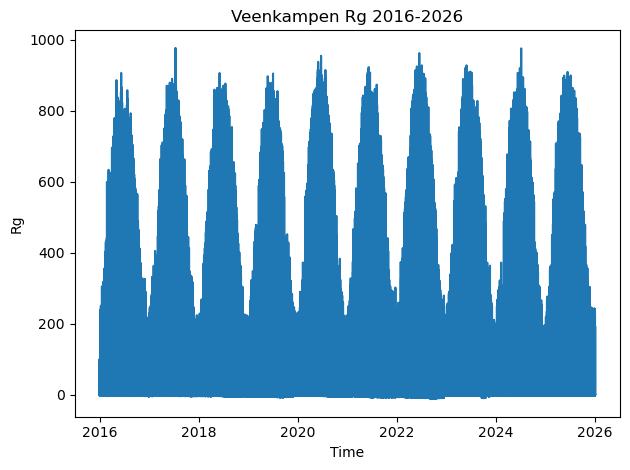

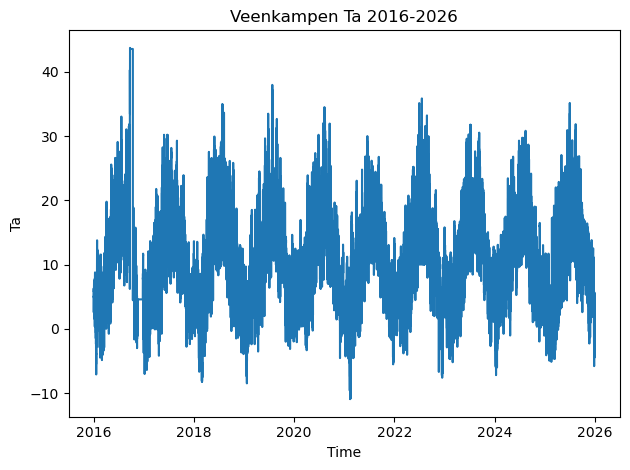

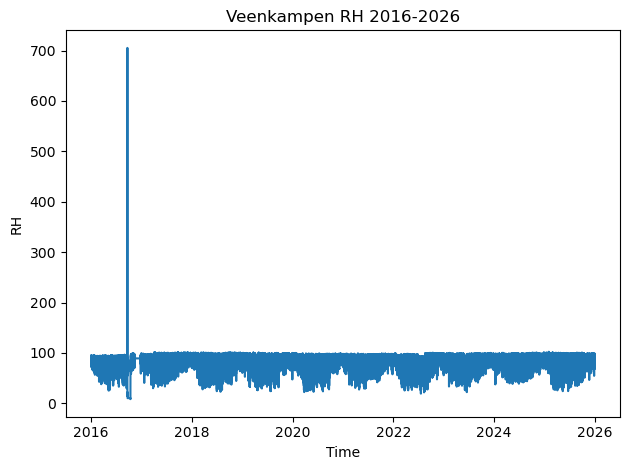

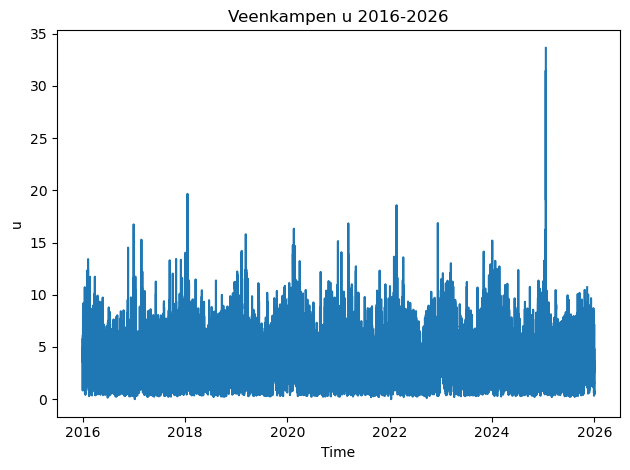

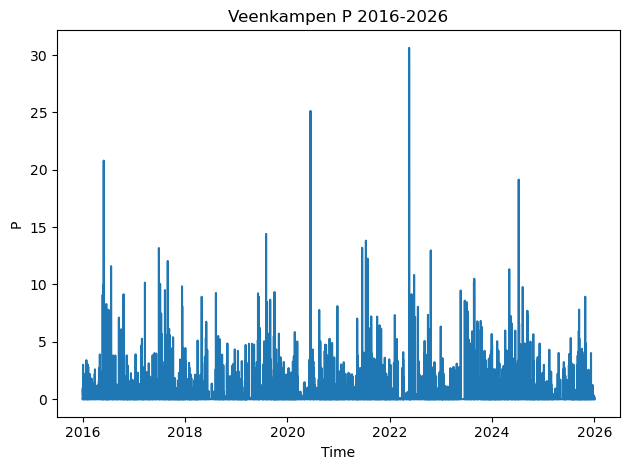

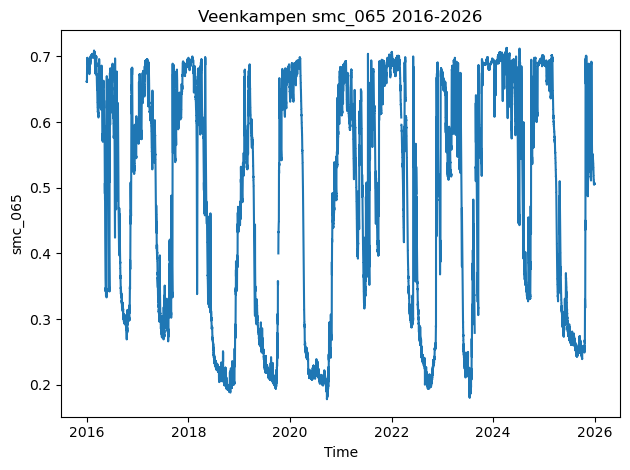

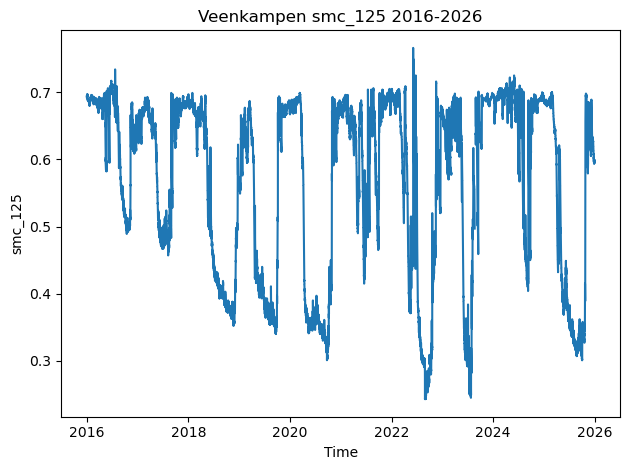

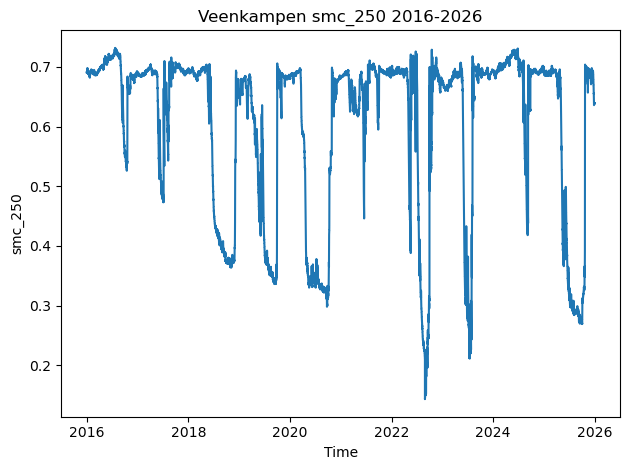

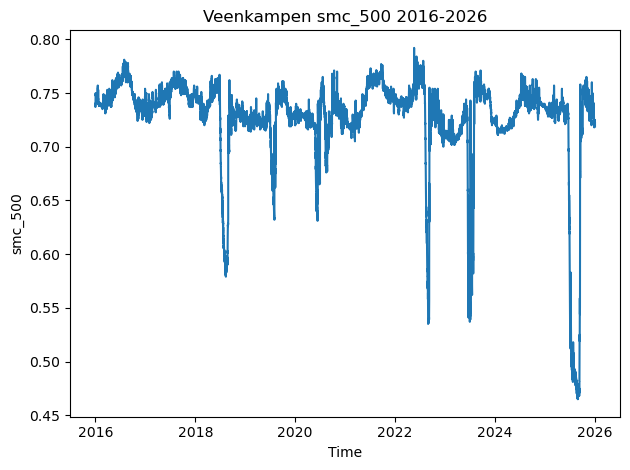

In [7]:
import matplotlib.pyplot as plt
vk = pd.read_csv(f"Data_Meteo_Veenkampen_{start_date.year}-{end_date.year}.csv", sep=";")
vk['date-time'] = pd.to_datetime(vk['date-time'])
start_year = vk['year'].min()
end_year = vk['year'].max()
print(vk)

variables = ['Rg','Ta','RH','u','P','smc_065','smc_125','smc_250','smc_500']

for var in variables:
    plt.figure()
    plt.plot(vk['date-time'], vk[var])
    plt.title(f"Veenkampen {var} {start_year}-{end_year}")
    plt.xlabel("Time")
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()
